In [16]:
from CADETProcess.optimization import OptimizationProblem
from CADETProcess.processModel import Inlet, MCT, Outlet, TubularReactor
from CADETProcess.optimization import SLSQP, U_NSGA3, Pathos, Joblib, COBYLA, TrustConstr
from CADETProcess.processModel import ComponentSystem,MassActionLaw, LumpedRateModelWithoutPores
from CADETProcess.processModel import FlowSheet
from CADETProcess.processModel import Process
from CADETProcess.simulator import Cadet
from scipy.optimize import minimize, least_squares
from scipy.ndimage import convolve1d
from scipy.ndimage import gaussian_filter1d


import logging
from scipy import interpolate
from IPython import display

from utils import *

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:
df = process_roi_txt_to_excel("Phas_6_M11_Internode_below_leaf.txt", "Phas_6_M11_Internode_below_leaf.xlsx")

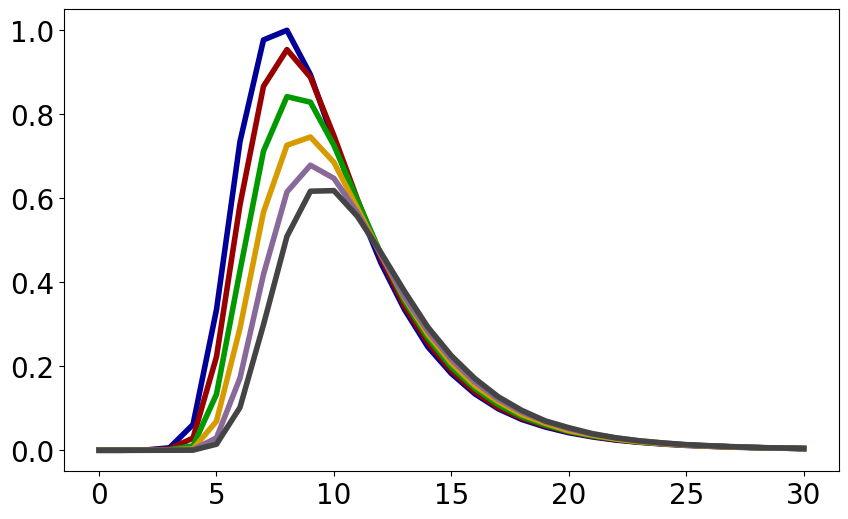

In [18]:
xi=list(df.columns)
t=df.index.to_numpy()

data_cor=df[xi].to_numpy(dtype=float)

data_unc=df[xi].to_numpy(dtype=float)*np.exp(-0.000567*60*t.reshape(len(t),1))

steps=len(data_cor)

d_xi=[]

for i in range(1,len(xi)):
     d_xi.append(float(xi[i])-float(xi[i-1]))

xi=list(np.array(xi)[[6,7,8,9,10,11]])


exp_data = data_cor*np.exp(-0.000567*60*t.reshape(len(t),1))



weights = 1 #/ np.mean(exp_data, axis=0)


normalized_data = (data_cor[:,[6,7,8,9,10,11]].T  - data_cor[:,[6,7,8,9,10,11]].T .min(axis=1, keepdims=True))

normalized_data[:, :2] = 0

normalized_data=normalized_data.T




# Transpose and smooth
monotonic_data = normalized_data.copy().T

for i in range(monotonic_data.shape[0]):
    # Smooth first 4 values only
    monotonic_data[i, :3] = gaussian_filter1d(monotonic_data[i, :3], sigma=0.5)
    
# Transpose back
smooth_exp_data = monotonic_data.T / np.exp(0.000567*60*t.reshape(len(t), 1))

exp_data = smooth_exp_data / np.max(smooth_exp_data)



num_new_rows = 1
num_columns = exp_data.shape[1]

new_rows = np.zeros((num_new_rows, num_columns))


exp_data = np.vstack((new_rows, exp_data))
t = np.hstack((t,[150.]))


plt.plot(exp_data)


In [19]:
t

array([  0.,   5.,  10.,  15.,  20.,  25.,  30.,  35.,  40.,  45.,  50.,
        55.,  60.,  65.,  70.,  75.,  80.,  85.,  90.,  95., 100., 105.,
       110., 115., 120., 125., 130., 135., 140., 145., 150.])

In [20]:
def setup_process(x):
    
    p_volumetric_flow_rate_const_t0 = x[0]
    p_mct1_e12 = x[1]
    p_total_porosity = x[2]
    p_col_dispersion = x[3]
    p_mct_disp = x[4]

        
  # Initialize the component system and flow sheet
    component_system = ComponentSystem(1)
    mct_flow_sheet = FlowSheet(component_system)

    # Create the units
    inlet = Inlet(component_system, name='inlet')
    leaf = LumpedRateModelWithoutPores(component_system, name='leaf')
    mct1 = MCT(component_system, nchannel=2, name='mct1')
    outlet = Outlet(component_system, name='outlet')

    leaf.discretization.ncol = 20
    mct1.discretization.ncol = 30


    reaction_system = MassActionLaw(component_system)
    reaction_system.add_reaction(
    indices=[0],
    coefficients=[-1],
    k_fwd=0.00056729782996132,
    k_bwd=0,)

    mct1.bulk_reaction_model = reaction_system


    mct_flow_sheet.add_unit(inlet)
    mct_flow_sheet.add_unit(leaf)
    mct_flow_sheet.add_unit(mct1)
    mct_flow_sheet.add_unit(outlet)
    
    inlet.flow_rate = p_volumetric_flow_rate_const_t0

    leaf.total_porosity = p_total_porosity
    leaf.length = 0.01
    leaf.diameter = np.sqrt(1/np.pi)*17
    leaf.axial_dispersion = p_col_dispersion

    mct_flow_sheet.add_connection(inlet, leaf)
    mct_flow_sheet.add_connection(leaf, mct1, destination_port = 'channel_0')
    mct_flow_sheet.add_connection(mct1, outlet, origin_port = 'channel_0')
 
    process = Process(mct_flow_sheet, 'Tracer_Transport')

    mct1.length =  xi[-1]/1000
    
    mct1.channel_cross_section_areas = [1,1] 
    
    mct1.axial_dispersion = p_mct_disp
    
    mct1.solution_recorder.write_solution_bulk = 1

    mct1.exchange_matrix = np.array([
                                    [[0.0], [p_mct1_e12]],
                                    [[0.0], [0.0]],
                                    ])
                                


    process.cycle_time = 60*t[-1]

    _ = process.add_event('Base', 'flow_sheet.inlet.c', [1],0)
    _ = process.add_event('Start', 'flow_sheet.inlet.c', [1],0.1)
    _ = process.add_event('Stop', 'flow_sheet.inlet.c', [0],6*60)
        
    #plt.plot(t_curve, curve_modified, label="Smoothed Profile")
    #_ = process.plot_events()    

        
    return process

In [21]:
# Define min and max values for each parameter
param_bounds = {
    'volumetric_flow_rate_const': (1e-05, 2e-04),  # log-scaling, volumetric_flow_rate_const
    'mct1_e12': (1.53039589e-5, 6.12158354e-01),  # log-scaling, mct1_e12
    'total_porosity': (0.1, 0.99),          # linear scaling, total_porosity
    'col_dispersion': (2.83319089e-12, 1.13327635e-04),  # log-scaling, col_dispersion
    'mct_disp': (2.83319089e-10, 1.13327635e-4)}

    
def normalize_parameters(x):
    normalized_x = []
    for i, param in enumerate(param_bounds):
        min_val, max_val = param_bounds[param]
        
        if min_val > 0 and (max_val / min_val) > 100:  # If the range is large, use log scaling
            norm_param = (np.log(x[i]) - np.log(min_val)) / (np.log(max_val) - np.log(min_val))
        else:  # For compact ranges, use min-max scaling
            norm_param = (x[i] - min_val) / (max_val - min_val)
        
        normalized_x.append(norm_param)
    
    return np.array(normalized_x)

def denormalize_parameters(norm_x):
    x = []
    for i, param in enumerate(param_bounds):
        min_val, max_val = param_bounds[param]
        
        if min_val > 0 and (max_val / min_val) > 100:  # Log scaling for large ranges
            param_value = np.exp(norm_x[i] * (np.log(max_val) - np.log(min_val)) + np.log(min_val))
        else:  # Min-max scaling for compact ranges
            param_value = norm_x[i] * (max_val - min_val) + min_val
        
        x.append(param_value)
    
    return np.array(x)

def analyze_parameters(norm_param_values, param_bounds=param_bounds):
    """
    Analyze parameters and print their names, denormalized values, and normalized values.

    Args:
        norm_param_values (list): Normalized parameter values (0-1 range).
        param_bounds (dict): Dictionary with parameter names as keys and boundary tuples as values.

    Returns:
        None: Prints the analysis.
    """
    print(f"{'Name':<30}{'Denormalized Value':<20}{'Normalized Value':<10}")
    print("-" * 65)

    # Denormalize parameters
    param_values = denormalize_parameters(norm_param_values)

    for i, (name, bounds) in enumerate(param_bounds.items()):
        value = param_values[i]
        norm_param = norm_param_values[i]

        print(f"{name:<30}{value:<20.8e}{norm_param:<10.2f}")

In [22]:
def mct_obj_norm(x_norm):

    x = denormalize_parameters(x_norm)
    
    process = setup_process(x)
    
    simulation_results = simulator.simulate(process) 
    time_new = np.arange(t[0]*60,t[-1]*60+5*60,5*60)

    mct1 = process.flow_sheet.units[2]

    lenghts = [x / 1000 for x in xi]

    eval_location1 = list(np.array(lenghts[:]))

    cb_mct1 = interpolate_cb_from_simulation_results(simulation_results, mct1, time_new, axial_positions_new = eval_location1)
    calc_data_mct1 = np.sum(cb_mct1, axis=2).squeeze()
   

    calc_data = calc_data_mct1 # np.hstack((calc_data_mct1,calc_data_mct2))
    calc_data = calc_data/np.max(calc_data)
    residuals = calc_data-exp_data

    weighted_residuals = residuals * weights
    
    SSQ = np.sum(weighted_residuals**2)
    
    print(np.array(x_norm), SSQ)
    
    plot_fit(time_new, calc_data, exp_data)

    return SSQ

In [23]:
def mct_obj_res(x_norm):

    x = denormalize_parameters(x_norm)

    process = setup_process(x)

    simulation_results = simulator.simulate(process) 
    time_new = np.arange(t[0]*60,t[-1]*60+5*60,5*60)

    mct1 = process.flow_sheet.units[2]

    lenghts = [x / 1000 for x in xi]

    eval_location1 = list(np.array(lenghts[:]))

    cb_mct1 = interpolate_cb_from_simulation_results(simulation_results, mct1, time_new, axial_positions_new = eval_location1)
    calc_data_mct1 = np.sum(cb_mct1, axis=2).squeeze()


    calc_data = calc_data_mct1 # np.hstack((calc_data_mct1,calc_data_mct2))
    calc_data = calc_data/np.max(calc_data)

    residuals = calc_data-exp_data

    weighted_residuals = residuals * weights
    
    SSQ = np.sum(weighted_residuals**2)
    plot_fit(time_new, calc_data, exp_data)

    return weighted_residuals

In [24]:
def plot_fit(time, calc_data, experimental_data):

    display.clear_output(wait=True)
    
    res=np.sum(((calc_data.ravel()-exp_data.ravel())**2).reshape(len(t),len(xi)),axis=1)
    

    fig = plt.figure(figsize=(15,5))
    ax1 = fig.add_subplot(121)
    ax1.plot(time/60,calc_data[:], label="mct1", color='k', linewidth=1)
    ax1.plot(time/60,res, label="res", color='b')
    ax1.plot(time/60,experimental_data,'.')
    
    #ax1.legend()

    # ax2 = fig.add_subplot(132)

    # ax3 = fig.add_subplot(133)
    # ax3.plot(self.ssq_list, label=ssq)
    # v_text='v:'+str(v)
    # ax3.set_title(v_text)
    # ax3.legend()

    display.display(fig)
    plt.close(fig)

In [25]:
simulator = Cadet()    
simulator.time_resolution = 60
simulator.use_dll = True

In [26]:
analyze_parameters([0.50708163, 0.24202066, 0.19886317, 0.44241749, 0.05413249])

Name                          Denormalized Value  Normalized Value
-----------------------------------------------------------------
volumetric_flow_rate_const    1.06345510e-04      0.51      
mct1_e12                      1.98882874e-04      0.24      
total_porosity                2.76988221e-01      0.20      
col_dispersion                6.53973478e-09      0.44      
mct_disp                      5.69546639e-10      0.05      


In [1]:
1.06345510e-04*(1/1.66667e-5), 1.06345510e-04*(1/1.66667e-5)*0.2333405528904155/100

(6.380717838564322, 0.014888802282883357)

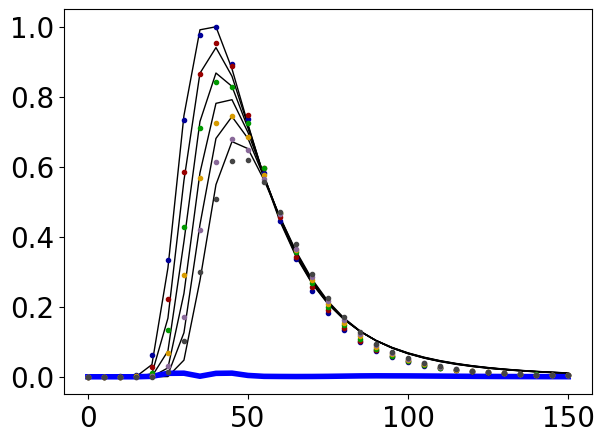

Optimization terminated successfully.
         Current function value: 0.127721
         Iterations: 140
         Function evaluations: 241


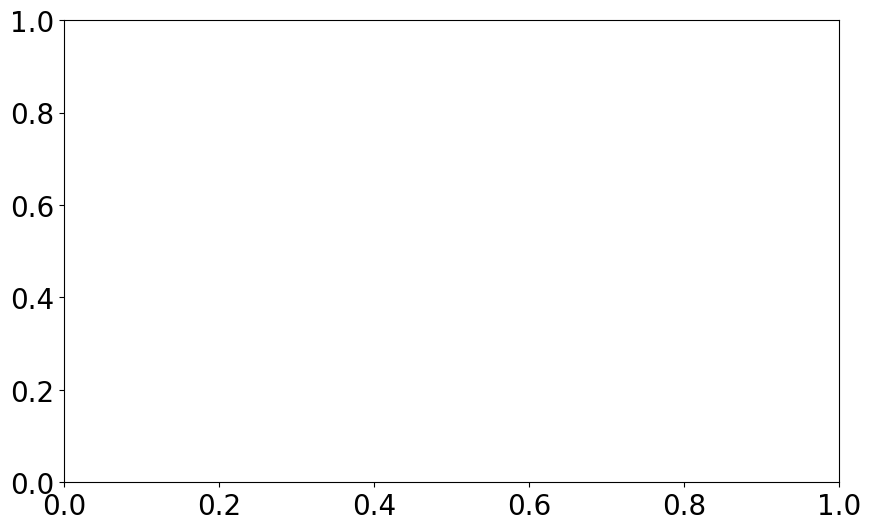

In [28]:
x0 = np.array([0.3456949 , 0.28741204, 0.12653788, 0.40005023 ,
       0.07877426])

# Initialize the plot
fig, ax = plt.subplots()

weights = 1 / np.max(exp_data, axis=0)

fig.canvas.draw()
display.display(fig)

result_nm= minimize(
    fun=mct_obj_norm,
    x0=x0,
    method='Nelder-Mead',
     bounds= (5*((0,1),)),
       options = {
       'disp': True,
       'maxfun': 2000
       })

In [29]:
result_nm.x

array([0.50708163, 0.24202066, 0.19886317, 0.44241749, 0.05413249])

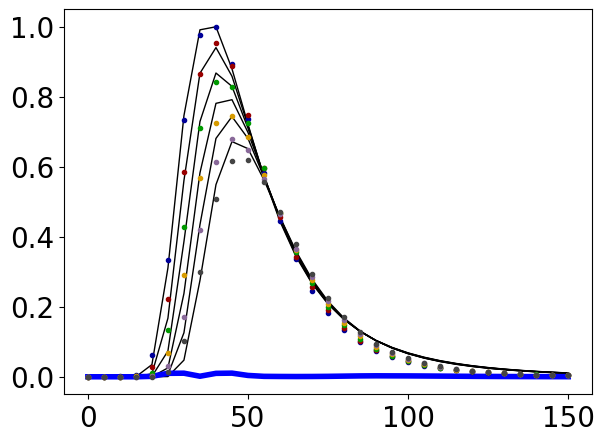

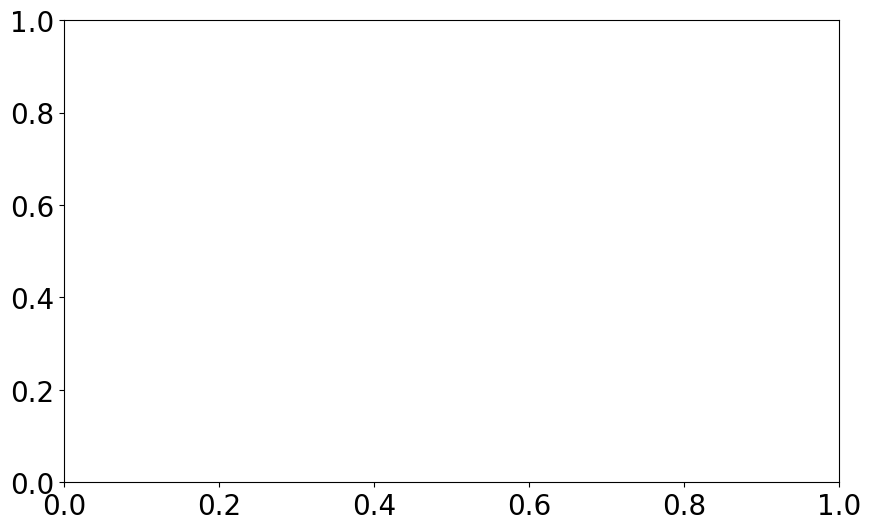

In [30]:
x0 = result_nm.x

# Initialize the plot
fig, ax = plt.subplots()

weights = 1 / np.max(exp_data, axis=0)

fig.canvas.draw()
display.display(fig)
result_grad= minimize(
    fun=mct_obj_norm,
    x0=x0,
    method='L-BFGS-B',
    jac = '3-point',
     bounds= (5*((0,1),)),
       options = {
       'disp': True,
       'maxfun': 2000
       })

In [31]:
result_grad.x

array([0.50708163, 0.24202066, 0.19886317, 0.44241749, 0.05413249])

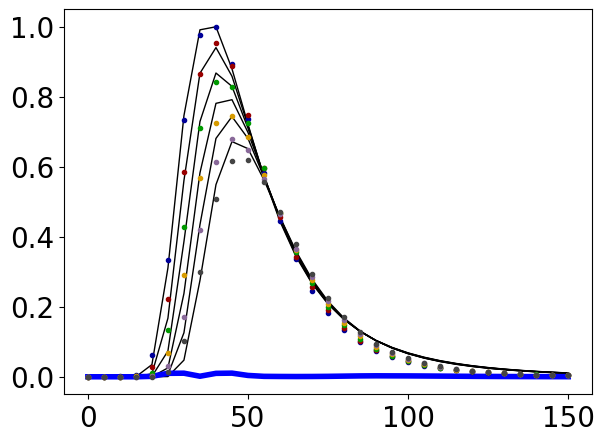

Parameter 0: ±0.2333405528904155%
Parameter 1: ±1.8906122159146423%
Parameter 2: ±0.748590764041802%
Parameter 3: ±0.13535559380756457%
Parameter 4: ±2999.032670944921%


In [32]:
x_best_fit = result_grad.x

def compute_jacobian(f, x, eps=None):
    """Computes numerical Jacobian using central difference with adaptive epsilon."""
    x = np.asarray(x)
    n_params = len(x)
    f_x = np.asarray(f(x)).ravel()
    n_outputs = len(f_x)
    J = np.zeros((n_outputs, n_params))

    if eps is None:
        eps = np.sqrt(np.finfo(float).eps) * np.maximum(1.0, np.abs(x))

    for i in range(n_params):
        x_step = np.zeros_like(x)
        x_step[i] = eps[i]

        f_plus = np.asarray(f(x + x_step)).ravel()
        f_minus = np.asarray(f(x - x_step)).ravel()

        J[:, i] = (f_plus - f_minus) / (2 * eps[i])

    return J



# Compute the Jacobian
J = compute_jacobian(mct_obj_res, x_best_fit)

# Step 3: Compute the covariance matrix
JTJ_inv = np.linalg.inv(J.T @ J)  # (J^T J)^-1
sigma_squared = np.var(mct_obj_res(x_best_fit))  # Estimate variance of residuals
C = JTJ_inv * sigma_squared  # Covariance matrix

# Step 4: Compute parameter uncertainties
param_uncertainties = np.sqrt(np.abs(np.diag(C)))  # Extract uncertainties
rel_param_uncertanties = param_uncertainties / np.abs(x_best_fit)

# Print results
for i, uncertainty in enumerate(rel_param_uncertanties):
    print(f"Parameter {i}: ±{uncertainty*100}%")